# 03. Análise Quantitativa de Data Drift e Concept Drift

Este notebook executa testes estatísticos para verificar mudanças na distribuição das variáveis explicativas (Data Drift) e da variável-alvo (Concept Drift) ao longo das partições temporais D0, D1 e D2.

Técnicas utilizadas:
* **Kolmogorov-Smirnov (KS)** e **Population Stability Index (PSI)** para variáveis numéricas.
* **Qui-Quadrado** para variáveis categóricas (`country`, `entry_status`).
* Discussão final relacionando o drift identificado com a degradação de desempenho observada no Notebook 04.

In [6]:
import sys
import os
import pandas as pd
import numpy as np
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('..'))
from src.data_processing import compute_psi, categorical_drift_test

sns.set_theme(style="whitegrid")

# Carga de dados físicos gerados no Épico 1
d0 = pd.read_csv('../data/processed/d0.csv')
d1 = pd.read_csv('../data/processed/d1.csv')
d2 = pd.read_csv('../data/processed/d2.csv')

print(f"Instâncias - D0: {len(d0):,} | D1: {len(d1):,} | D2: {len(d2):,}")

Instâncias - D0: 163,932 | D1: 57,497 | D2: 51,350


## 1. Teste Kolmogorov-Smirnov e PSI (Data Drift em Variáveis Numéricas)

Utilizamos o teste não paramétrico bicaudal de Kolmogorov-Smirnov para comparar a distribuição empírica das variáveis numéricas entre D0 (histórico) e as partições D1 e D2, complementado pelo PSI (Population Stability Index), que é menos sensível ao tamanho amostral.

* **KS:** H0 = as amostras vêm da mesma distribuição. Se p-valor < 0.05, rejeitamos H0 (drift estatisticamente significativo).
* **PSI:** PSI < 0.10 (sem mudança relevante), 0.10–0.25 (mudança moderada), > 0.25 (mudança severa).

In [7]:
num_features = [
    'rank', 'peak_rank', 'weeks_on_chart', 'consecutive_weeks',
    'album_age_days', 'dist_from_peak', 'rank_jump_prev'
]

drift_results = []

for feat in num_features:
    # KS entre D0 e D1 / D0 e D2
    stat_d1, p_d1 = ks_2samp(d0[feat].dropna(), d1[feat].dropna())
    stat_d2, p_d2 = ks_2samp(d0[feat].dropna(), d2[feat].dropna())

    # PSI entre D0 e D1 / D0 e D2
    psi_d1 = compute_psi(d0[feat].dropna().values, d1[feat].dropna().values)
    psi_d2 = compute_psi(d0[feat].dropna().values, d2[feat].dropna().values)

    drift_results.append({
        'Atributo': feat,
        'KS (D0 vs D1)': stat_d1,
        'p-valor (D1)': p_d1,
        'PSI (D0 vs D1)': psi_d1,
        'Drift D1?': 'Sim' if (p_d1 < 0.05 or psi_d1 >= 0.10) else 'Não',
        'KS (D0 vs D2)': stat_d2,
        'p-valor (D2)': p_d2,
        'PSI (D0 vs D2)': psi_d2,
        'Drift D2?': 'Sim' if (p_d2 < 0.05 or psi_d2 >= 0.10) else 'Não'
    })

df_drift = pd.DataFrame(drift_results)
display(df_drift.round(4))

,Atributo,KS (D0 vs D1),p-valor (D1),PSI (D0 vs D1),Drift D1?,KS (D0 vs D2),p-valor (D2),PSI (D0 vs D2),Drift D2?
0,rank,0.0010,1.0,0.0000,Não,0.0047,0.3452,0.0002,Não
1,peak_rank,0.1417,0.0,0.0935,Sim,0.1618,0.0000,0.1348,Sim
2,weeks_on_chart,0.3148,0.0,0.5680,Sim,0.3474,0.0000,0.6380,Sim
3,consecutive_weeks,0.2233,0.0,0.3024,Sim,0.2092,0.0000,0.2586,Sim
4,album_age_days,0.0979,0.0,0.0606,Sim,0.1413,0.0000,0.1172,Sim
5,dist_from_peak,0.1180,0.0,0.0720,Sim,0.1336,0.0000,0.0938,Sim
6,rank_jump_prev,0.0276,0.0,0.0111,Sim,0.0331,0.0000,0.0153,Sim


## 2. Teste Qui-Quadrado (Data Drift em Variáveis Categóricas)

Verificamos se a distribuição de `country` e `entry_status` mudou de forma estatisticamente significativa entre os períodos. Como `country` tem participação fixa por desenho amostral, o resultado aqui serve principalmente para confirmar estabilidade estrutural; já `entry_status` reflete diretamente o comportamento de entrada/saída/permanência dos álbuns no ranking, sendo mais sensível a mudanças reais de consumo.

,Atributo,Chi2 (D0 vs D1),p-valor (D1),Drift D1?,Chi2 (D0 vs D2),p-valor (D2),Drift D2?
0,country,3.2097,0.5234,Não,1.7599,0.7798,Não
1,entry_status,311.5426,0.0000,Sim,340.7908,0.0000,Sim


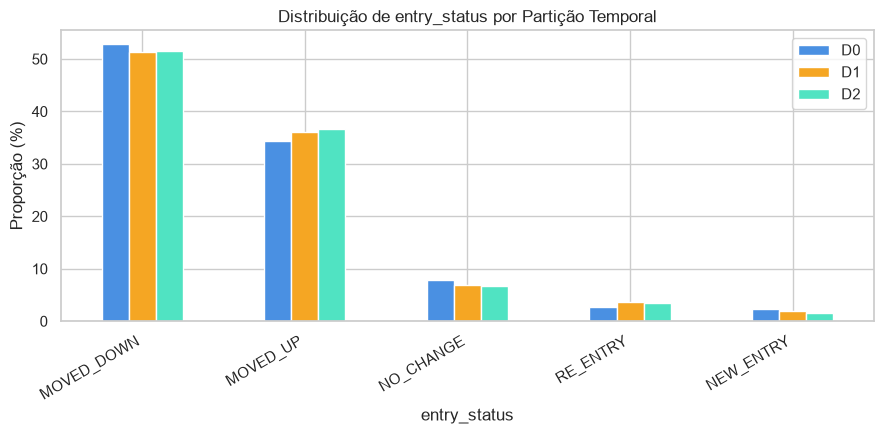

In [8]:
cat_features = ['country', 'entry_status']
cat_drift_results = []

for feat in cat_features:
    chi2_d1, p_d1 = categorical_drift_test(d0[feat], d1[feat])
    chi2_d2, p_d2 = categorical_drift_test(d0[feat], d2[feat])

    cat_drift_results.append({
        'Atributo': feat,
        'Chi2 (D0 vs D1)': chi2_d1,
        'p-valor (D1)': p_d1,
        'Drift D1?': 'Sim' if p_d1 < 0.05 else 'Não',
        'Chi2 (D0 vs D2)': chi2_d2,
        'p-valor (D2)': p_d2,
        'Drift D2?': 'Sim' if p_d2 < 0.05 else 'Não'
    })

df_cat_drift = pd.DataFrame(cat_drift_results)
display(df_cat_drift.round(4))

# Visualização complementar: distribuição de entry_status ao longo das partições
fig, ax = plt.subplots(figsize=(9, 4.5))
entry_status_dist = pd.DataFrame({
    'D0': d0['entry_status'].value_counts(normalize=True),
    'D1': d1['entry_status'].value_counts(normalize=True),
    'D2': d2['entry_status'].value_counts(normalize=True)
}).fillna(0) * 100

entry_status_dist.plot(kind='bar', ax=ax, color=['#4A90E2', '#F5A623', '#50E3C2'])
ax.set_title("Distribuição de entry_status por Partição Temporal")
ax.set_ylabel("Proporção (%)")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 3. Concept Drift (Variável-Alvo)

Analisamos se a proporção de álbuns que sobem de posição (`target_trend_up` = 1) mudou ao longo das eras histórica, recente e futura.

,Caiu/Manteve (0),Subiu (1)
D0 (Histórico),63.6%,36.4%
D1 (Recente),61.79%,38.21%
D2 (Futuro),61.28%,38.72%


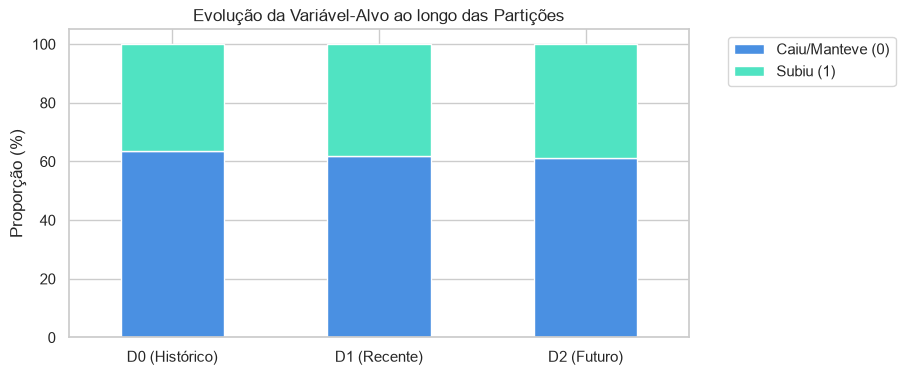

In [9]:
target_dist = pd.DataFrame({
    'D0 (Histórico)': d0['target_trend_up'].value_counts(normalize=True),
    'D1 (Recente)': d1['target_trend_up'].value_counts(normalize=True),
    'D2 (Futuro)': d2['target_trend_up'].value_counts(normalize=True)
}).T * 100

target_dist.columns = ['Caiu/Manteve (0)', 'Subiu (1)']
display(target_dist.round(2).astype(str) + '%')

target_dist.plot(kind='bar', stacked=True, figsize=(8, 4), color=['#4A90E2', '#50E3C2'])
plt.title("Evolução da Variável-Alvo ao longo das Partições")
plt.ylabel("Proporção (%)")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

## 4. Correlação entre Drift e Degradação de Desempenho (RN09.2)

Esta seção deve ser preenchida **após** a execução do Notebook 04, cruzando os atributos com maior KS/PSI/Chi² com a queda de métricas de M0 observada em D1 e D2.

Atributos ordenados por magnitude de drift (D0 vs D2):


,Atributo,KS (D0 vs D2),PSI (D0 vs D2),Drift D2?
2,weeks_on_chart,0.347392,0.637954,Sim
3,consecutive_weeks,0.209153,0.258634,Sim
1,peak_rank,0.161768,0.134828,Sim
4,album_age_days,0.141311,0.117209,Sim
5,dist_from_peak,0.133560,0.093824,Sim
6,rank_jump_prev,0.033139,0.015308,Sim
0,rank,0.004728,0.000201,Não


C:\Users\eduar\AppData\Local\Temp\ipykernel_18064\2019037552.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ranking_drift, x='PSI (D0 vs D2)', y='Atributo', palette='rocket')


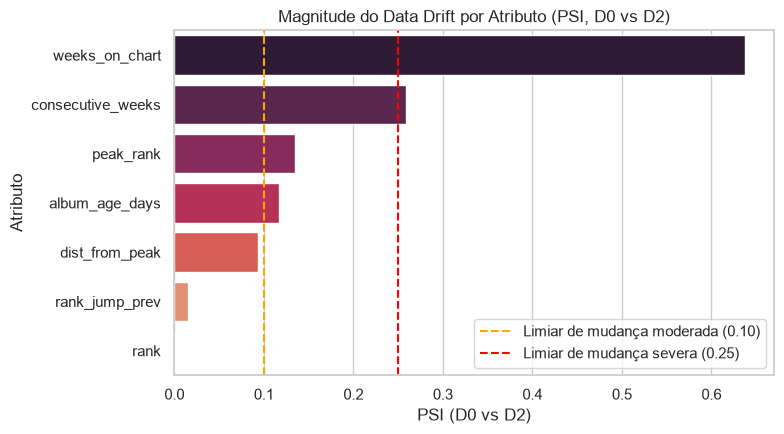

In [11]:
# Ranking dos atributos por magnitude de drift (ordenados pelo PSI D0 vs D2)
ranking_drift = df_drift[['Atributo', 'KS (D0 vs D2)', 'PSI (D0 vs D2)', 'Drift D2?']]\
    .sort_values(by='PSI (D0 vs D2)', ascending=False)

print("Atributos ordenados por magnitude de drift (D0 vs D2):")
display(ranking_drift)

plt.figure(figsize=(8, 4.5))
sns.barplot(data=ranking_drift, x='PSI (D0 vs D2)', y='Atributo', palette='rocket')
plt.axvline(0.10, color='orange', linestyle='--', label='Limiar de mudança moderada (0.10)')
plt.axvline(0.25, color='red', linestyle='--', label='Limiar de mudança severa (0.25)')
plt.title("Magnitude do Data Drift por Atributo (PSI, D0 vs D2)")
plt.legend()
plt.tight_layout()
plt.show()